## Introduction



In this lesson, we'll learn how Convolutional Neural Networks (CNNs) work and how to use them to classify images. CNNs are specialized neural networks for processing visual data. Their architecture is inspired by the way our brains process visual information.

### Why CNNs?
Traditional neural networks (fully connected layers) fail to scale for high-dimensional image inputs. CNNs solve this by:
- Using **local receptive fields** to detect patterns.
- **Sharing weights** across space to reduce parameters.
- Capturing **hierarchical features**, from edges to object parts.

## 1. Load and Visualize Dataset

We'll use the Fashion-MNIST dataset, which contains 28x28 grayscale images of clothes (e.g., shirts, trousers). Each image is labeled into one of 10 classes.

Fashion-MNIST is a dataset built to replace the classic MNIST handwritten digits. It includes:
- 60,000 training images
- 10,000 test images
- 10 clothing categories

We'll first load and visualize some sample images to understand what we're working with.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


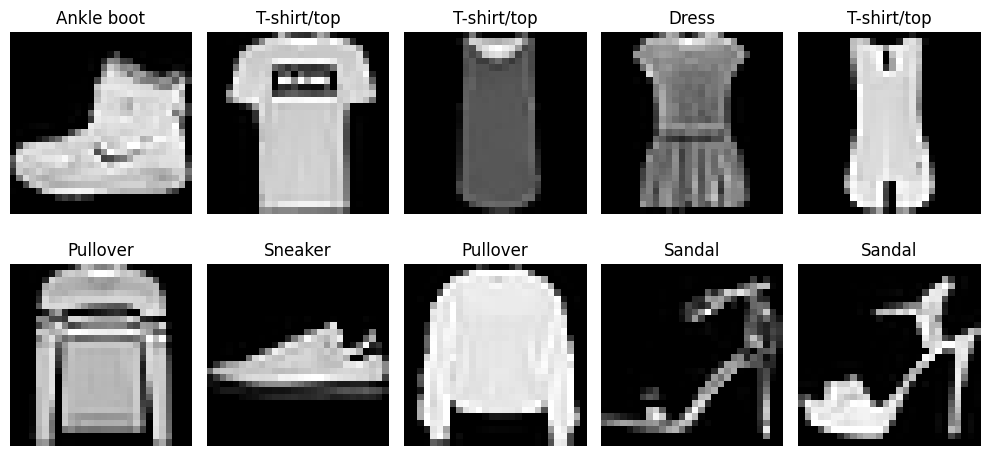

In [1]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Visualize some examples
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


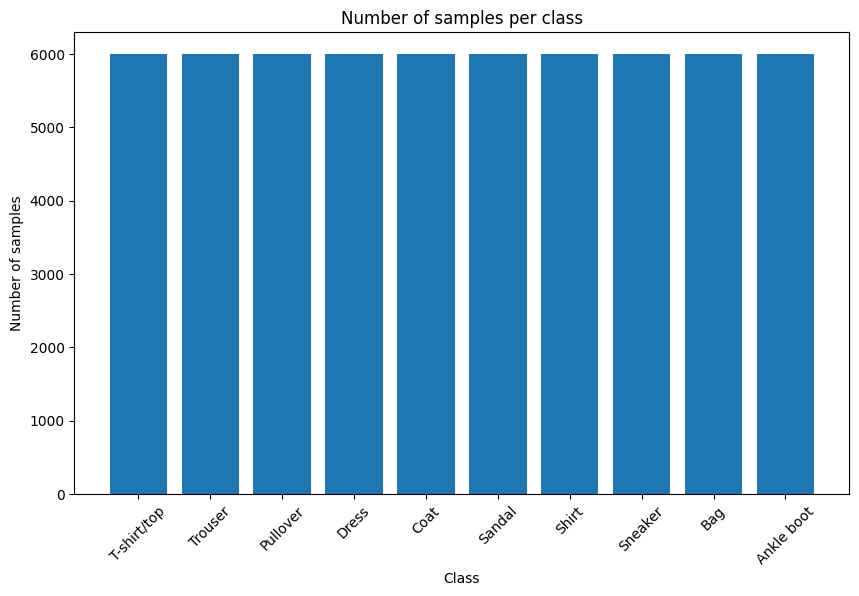

T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


In [13]:

from collections import Counter


labels = y_train

# Count the number of samples per class
class_counts = Counter(labels)

# Sort by class index
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]


# Plotting
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Number of samples per class')
plt.xticks(rotation=45)
plt.show()

# Optional: print counts for reference
for cls, count in zip(class_names, counts):
    print(f"{cls}: {count}")


In [14]:
y_train.shape

(60000,)

In [24]:
y_test.shape

(10000,)


### 2. Data Preprocessing

Before training, we need to prepare our data to fit the model:
1. **Reshape** the input images to add the channel dimension expected by CNNs.
2. **Normalize** pixel values to the [0, 1] range to speed up training.
3. **Encode** the labels using one-hot encoding for categorical classification.

We will use the `Rescaling` and `to_categorical` utilities provided by Keras.

In [2]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Rescaling
import tensorflow as tf

# Reshape to add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Convert labels to one-hot vectors
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Create a preprocessing layer for normalization
normalization_layer = Rescaling(1./255)
X_train = normalization_layer(X_train)
X_test = normalization_layer(X_test)



### 3. Build CNN model

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # First convolutional layer with 32 filters, 3x3 kernel, ReLU activation
    # Input shape is 28x28 pixels with 1 color channel (grayscale)
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    # Max pooling layer to reduce spatial dimensions by a factor of 2
    MaxPooling2D(2,2),
    # Second convolutional layer with 64 filters, 3x3 kernel, ReLU activation
    Conv2D(64, (3,3), activation='relu'),
    # Another max pooling layer to reduce size further
    MaxPooling2D(2,2),
    # Flatten the 2D feature maps into a 1D vector for dense layers
    Flatten(),
    # Fully connected (dense) layer with 128 neurons and ReLU activation
    #Learns intermediate features from the previous layers
    Dense(128, activation='relu'),
    # Output layer with 10 neurons (for 10 classes) and softmax activation
    #Produces the final probabilities for each class.
    Dense(10, activation='softmax')
])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

- **Layer Types:**
  - `Conv2D`: Convolutional layers that apply filters to the input image to detect features.
  - `MaxPooling2D`: Downsamples the spatial dimensions, reducing width and height.
  - `Flatten`: Converts the 2D feature maps into a 1D vector to feed into dense layers.
  - `Dense`: Fully connected layers that learn to classify based on extracted features.

- **Output Shape:**
  - The shape of the data after passing through each layer.
  - `None` means batch size can vary.
  - For example, `(None, 26, 26, 32)` means each image is transformed to 26x26 pixels with 32 feature maps.

- **Number of Parameters (Param #):**
  - These are the trainable weights and biases the model learns.
  - For example, the first Conv2D layer has 320 parameters (weights + biases).
  - Layers like MaxPooling have zero parameters because they perform fixed operations (like downsampling).

- **Total Parameters:**
  - The model has **225,034** trainable parameters in total.
  - This gives a sense of model complexity — more parameters often means a more powerful model but also higher risk of overfitting and longer training time.


### 4.Compile & Train

In [4]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train_cat, epochs=10, validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7645 - loss: 0.6622 - val_accuracy: 0.8651 - val_loss: 0.3624
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8845 - loss: 0.3178 - val_accuracy: 0.8909 - val_loss: 0.3091
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9012 - loss: 0.2664 - val_accuracy: 0.8847 - val_loss: 0.3109
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9160 - loss: 0.2351 - val_accuracy: 0.9074 - val_loss: 0.2641
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9237 - loss: 0.2045 - val_accuracy: 0.9081 - val_loss: 0.2596
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9315 - loss: 0.1791 - val_accuracy: 0.9030 - val_loss: 0.2853
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9403 - loss: 0.1610 - val_accuracy: 0.9097 - val_loss: 0.2557
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9477 - loss: 0.1384 

### 5. Evaluation

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict class probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test  # original integer labels

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.8993
Precision: 0.9030
Recall: 0.8993
F1 Score: 0.8997


In [7]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.78      0.82      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.89      0.81      0.85      1000
       Dress       0.93      0.90      0.91      1000
        Coat       0.75      0.94      0.84      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.72      0.72      0.72      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.97      0.96      0.97      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



**Class-by-Class Insights**

| Class         | Precision | Recall | F1-score | Support | Interpretation |
|---------------|-----------|--------|----------|---------|----------------|
| **T-shirt/top** | 0.87      | 0.78   | 0.82     | 1000    | High precision, but lower recall — model often misses true T-shirts. |
| **Trouser**     | 1.00      | 0.98   | 0.99     | 1000    | Excellent performance — almost perfect. |
| **Pullover**    | 0.89      | 0.81   | 0.85     | 1000    | Some confusion with Coat/Shirt — recall could improve. |
| **Dress**       | 0.93      | 0.90   | 0.91     | 1000    | Very good balance and consistent predictions. |
| **Coat**        | 0.75      | 0.94   | 0.84     | 1000    | High recall, but low precision — model often calls other classes "Coat". |
| **Sandal**      | 0.98      | 0.97   | 0.98     | 1000    | Excellent performance. |
| **Shirt**       | 0.72      | 0.72   | 0.72     | 1000    | Weakest class — model confuses with T-shirt, Pullover, and Coat. |
| **Sneaker**     | 0.94      | 0.97   | 0.96     | 1000    | Very strong and consistent. |
| **Bag**         | 0.97      | 0.96   | 0.97     | 1000    | Very strong — little confusion. |
| **Ankle boot**  | 0.98      | 0.95   | 0.97     | 1000    | Excellent — high confidence and recall. |


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


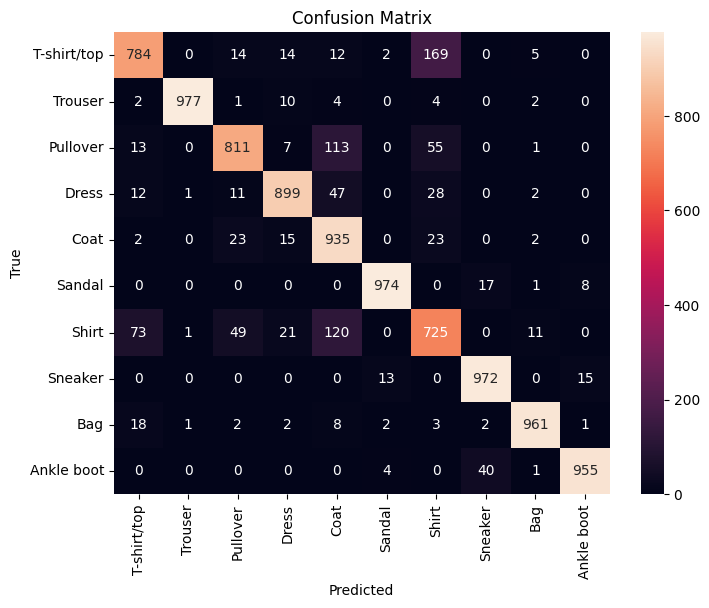

In [6]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Predict & confusion matrix
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


**Confusion Matrix Interpretation**

The confusion matrix reveals **common misclassifications** between visually similar classes:

- **Shirt vs. T-shirt/Top**: These garments are often confused due to similar shapes and textures. The model struggles to distinguish them in grayscale, low-resolution images.
- **Coat vs. Pullover**: Both are long-sleeved outer garments. In grayscale, they often appear similar, especially without color or detailed structure.
- **Coat vs. Shirt**: Shirts and coats can have overlapping silhouettes, especially in front-facing, simplified images.

These confusions are expected in Fashion-MNIST due to:
- Low resolution (28x28 pixels)
- Lack of color information
- Visual similarity in certain clothing categories



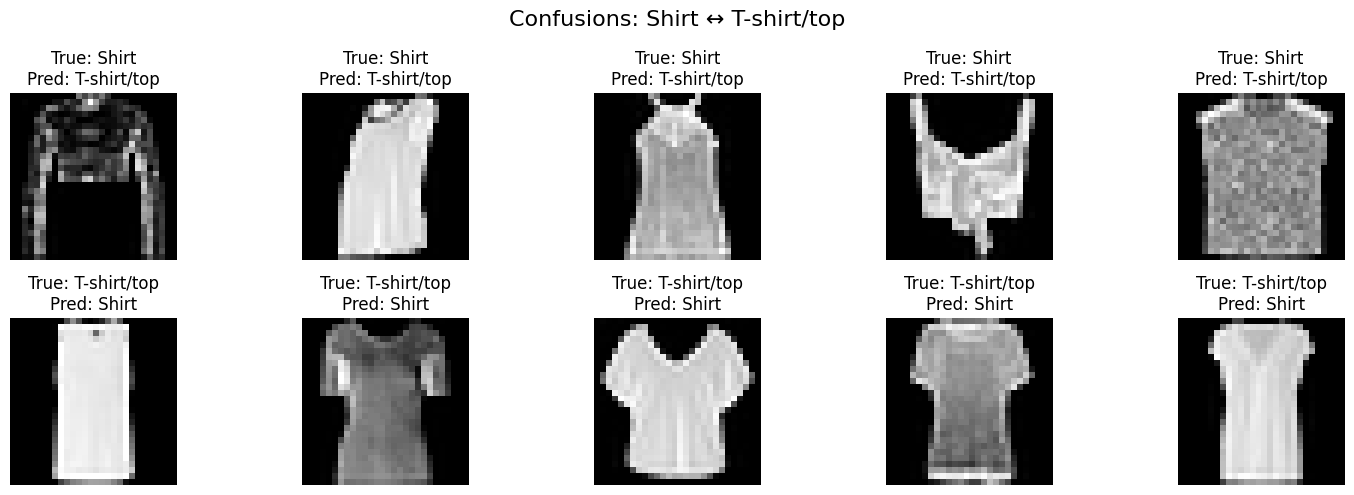

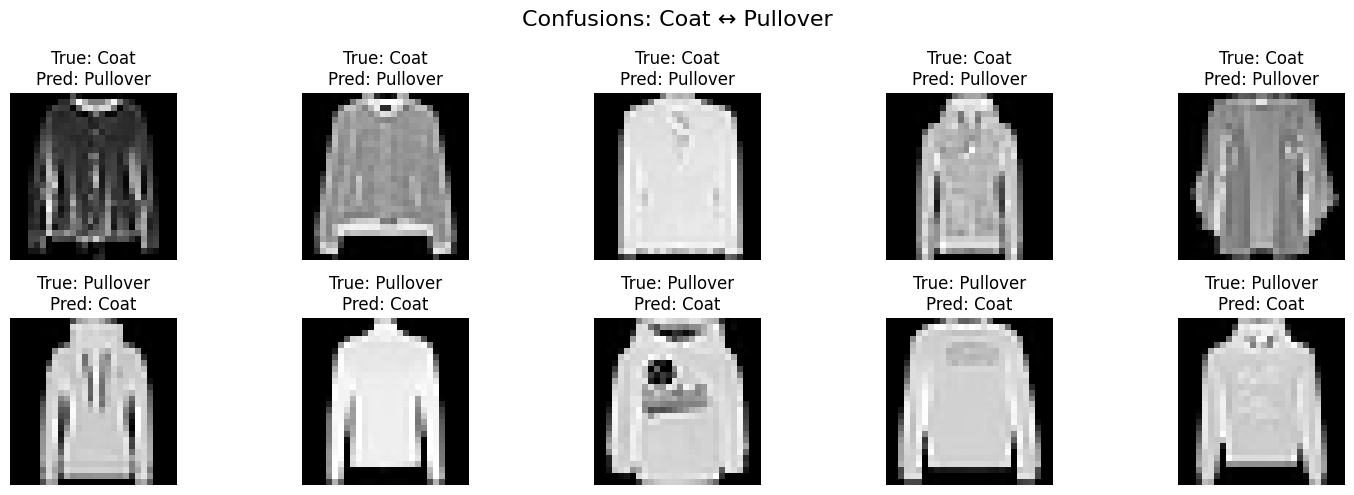

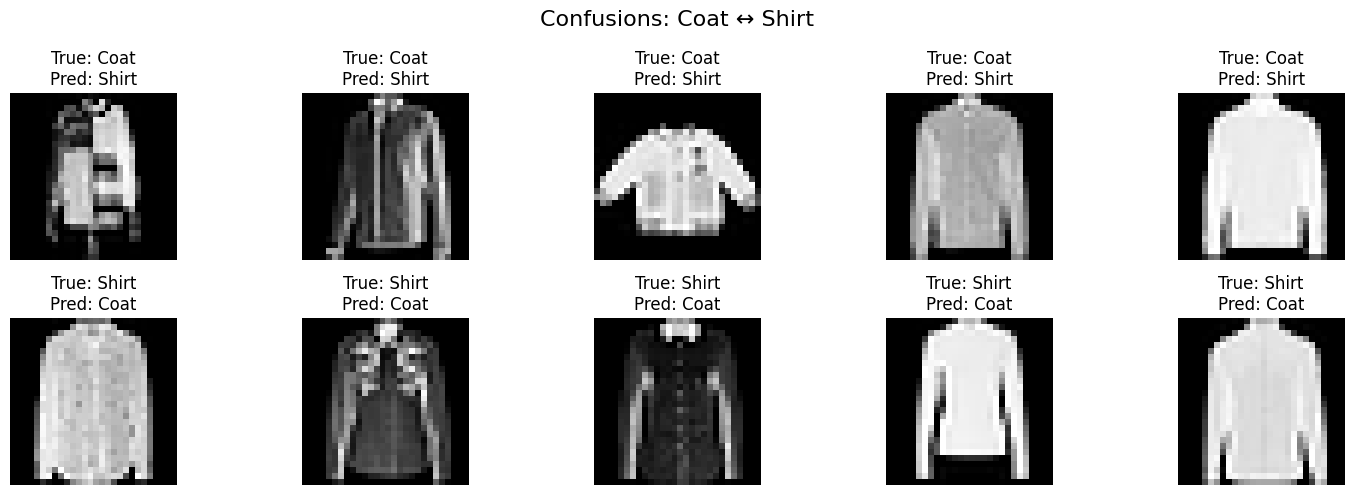

In [11]:
# Make sure y_pred and y_true are numpy arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Convert X_test to numpy if it's a TensorFlow tensor
X_test_np = X_test.numpy() if hasattr(X_test, 'numpy') else X_test

# Confusing class pairs to inspect
confusing_pairs = [
    (6, 0),  # Shirt vs T-shirt/top
    (4, 2),  # Coat vs Pullover
    (4, 6)   # Coat vs Shirt
]

# Function to plot misclassified images between two specific classes
def show_confusion_examples(y_true, y_pred, X, class1, class2, n=5):
    # Find indices of images where class1 was confused with class2 and vice versa
    idx_confused_1 = np.where((y_true == class1) & (y_pred == class2))[0]
    idx_confused_2 = np.where((y_true == class2) & (y_pred == class1))[0]

    fig, axes = plt.subplots(2, n, figsize=(15, 5))
    fig.suptitle(f"Confusions: {class_names[class1]} ↔ {class_names[class2]}", fontsize=16)

    for i in range(n):
        if i < len(idx_confused_1):
            ax = axes[0, i]
            ax.imshow(X[idx_confused_1[i]].reshape(28, 28), cmap='gray')
            ax.set_title(f"True: {class_names[class1]}\nPred: {class_names[class2]}")
            ax.axis('off')
        else:
            axes[0, i].axis('off')

        if i < len(idx_confused_2):
            ax = axes[1, i]
            ax.imshow(X[idx_confused_2[i]].reshape(28, 28), cmap='gray')
            ax.set_title(f"True: {class_names[class2]}\nPred: {class_names[class1]}")
            ax.axis('off')
        else:
            axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Show misclassifications for each confusing pair
for class1, class2 in confusing_pairs:
    show_confusion_examples(y_true, y_pred, X_test_np, class1, class2)


###  Suggestions for Improvement:
- Use **data augmentation** (e.g., rotation, shift, zoom) to help the model generalize.
- Add **more convolutional layers** or use **regularization** techniques (e.g., dropout, batch normalization).
- Try **transfer learning** with pretrained models on more complex datasets.

## Improving the Model: More Layers and Data Augmentation



### 1. Adding More Layers to the CNN

Adding more convolutional layers and dense layers can help the model learn more complex features from the images. Deeper models can extract higher-level patterns, which often improves accuracy — but they may also increase training time and risk of overfitting if not carefully managed.

**Key points:**
- More convolutional layers let the network detect more detailed features.
- Additional dense layers can improve classification power.
- Use techniques like dropout or batch normalization to reduce overfitting.




In [22]:
# Define deeper CNN model
model_more_layers = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_more_layers.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train on original data
history_more_layers = model_more_layers.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))

# Evaluate
loss, accuracy = model_more_layers.evaluate(X_test, y_test)
print(f"Test accuracy with more layers: {accuracy:.4f}")


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6572 - loss: 0.9287 - val_accuracy: 0.8250 - val_loss: 0.4861
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8318 - loss: 0.4549 - val_accuracy: 0.8534 - val_loss: 0.3968
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8627 - loss: 0.3771 - val_accuracy: 0.8585 - val_loss: 0.3894
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8759 - loss: 0.3387 - val_accuracy: 0.8754 - val_loss: 0.3359
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8870 - loss: 0.3081 - val_accuracy: 0.8804 - val_loss: 0.3278
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8986 - loss: 0.2772 - val_accuracy: 0.8907 - val_loss: 0.3096
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9027 - loss: 0.2603 - val_accuracy: 0.8836 - val_loss: 0.3313
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9117 - loss: 0.2354 - val_accuracy: 0.8955 - val_

### 2. Hyperparameters tuning

#### What is Early Stopping?

Early stopping is a technique used to prevent overfitting during training by monitoring the model’s performance on a validation set. Instead of training for a fixed number of epochs, the training stops automatically when the model's validation loss stops improving for a specified number of consecutive epochs (called "patience").

**Why use early stopping?**

- Prevents the model from overfitting by stopping before the model starts to memorize training data.
- Saves training time by stopping when further improvement is unlikely.
- Helps find the optimal number of epochs without manual tuning.

---

## How to use Early Stopping in Keras?

Keras provides a convenient `EarlyStopping` callback that you can add during model training. You specify:

- Which metric to monitor (usually `'val_loss'` or `'val_accuracy'`).
- How many epochs to wait (`patience`) for improvement before stopping.


In [30]:
from tensorflow.keras.callbacks import EarlyStopping
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Setup EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=3,           # stop if no improvement after 3 epochs
    restore_best_weights=True
)

# Train the model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=60,             # large max epochs, training will stop early if needed
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy with early stopping: {accuracy:.4f}")


Epoch 1/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7629 - loss: 0.6764 - val_accuracy: 0.8693 - val_loss: 0.3629
Epoch 2/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8844 - loss: 0.3221 - val_accuracy: 0.8740 - val_loss: 0.3458
Epoch 3/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8982 - loss: 0.2801 - val_accuracy: 0.8931 - val_loss: 0.2891
Epoch 4/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9105 - loss: 0.2466 - val_accuracy: 0.8992 - val_loss: 0.2768
Epoch 5/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9198 - loss: 0.2195 - val_accuracy: 0.9020 - val_loss: 0.2686
Epoch 6/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9305 - loss: 0.1930 - val_accuracy: 0.9087 - val_loss: 0.2563
Epoch 7/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9354 - loss: 0.1760 - val_accuracy: 0.9098 - val_loss: 0.2535
Epoch 8/60
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9428 - loss: 0.1559 - val_accuracy: 0.

> **Note:**  
> In addition to the number of epochs and early stopping, we can also experiment with other hyperparameters such as:
> - **Learning rate**: Controls how much the model updates weights during training.
> - **Batch size**: Number of samples processed before the model is updated.
> - **Optimizer**: The algorithm used for weight updates (e.g., Adam, SGD).
> - **Number of filters and kernel size** in convolutional layers.
> - **Dropout rate**: Helps prevent overfitting by randomly disabling neurons.
>
> Fine-tuning these hyperparameters can have a significant impact on model performance and training stability.



### 3. Data Augmentation

Data augmentation artificially increases the size and diversity of the training dataset by applying random transformations such as rotations, flips, zooms, and shifts. This helps the model generalize better and reduces overfitting, often leading to improved accuracy.

**Key points:**
- Augmented data simulates variations the model might see in real-world inputs.
- Keras provides an easy way to apply data augmentation on the fly during training.
- Common augmentations include rotation, width/height shift, zoom, and horizontal flip.

In [23]:

# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# Train model using data augmentation
history_aug = model_more_layers.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(X_test, y_test)
)

# Evaluate
loss_aug, accuracy_aug = model_more_layers.evaluate(X_test, y_test)
print(f"Test accuracy with data augmentation: {accuracy_aug:.4f}")


Epoch 1/20
  4/938 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.6058 - loss: 2.2312

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.7515 - loss: 0.7359 - val_accuracy: 0.8731 - val_loss: 0.3655
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.8164 - loss: 0.5045 - val_accuracy: 0.8669 - val_loss: 0.3845
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - accuracy: 0.8286 - loss: 0.4718 - val_accuracy: 0.8759 - val_loss: 0.3566
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8369 - loss: 0.4491 - val_accuracy: 0.8747 - val_loss: 0.3578
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8395 - loss: 0.4393 - val_accuracy: 0.8739 - val_loss: 0.3521
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.8474 - loss: 0.4191 - val_accuracy: 0.8822 - val_loss: 0.3283
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.8530 - loss: 0.4072 - val_accuracy: 0.8776 - val_loss: 0.3515
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8544 - loss: 0.3985 - val_accurac